In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
import sys
import copy
import json
import re
import string
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.patches import Wedge, Circle
from matplotlib.transforms import Bbox
from pathlib import Path
from astropy.time import Time

# --- Local project imports ---------------------------------------------------
BASE_DIR = Path('/home/andrewhughes/Projects/X-KAT/SwiftJ1727/new_meerkat/SpectroPol')
sys.path.insert(0, str(BASE_DIR / 'publication_work/QU_phenom/code'))
from faraday_model import load_results, update_model_from_params
from faraday_utils import ThinComponent

# --- FDF panel controls ------------------------------------------------------
PHI_RANGE  = 115            # x-axis: ±PHI_RANGE (rad m⁻²)
Y_RANGE    = (1e-4, 3e-1)   # (y_min, y_max) for log axis
N_PHI      = 4096           # Faraday-depth grid resolution
N_SAMPLES  = 100            # posterior samples per panel

# --- Polarisation-angle dial controls ----------------------------------------
DIAL_SCALE = 0.30           # dial diameter as fraction of axes height
DIAL_PAD   = 0.00           # padding from axes edge (axes fraction)
DIAL_SEP   = 0.00           # gap between adjacent dials (axes fraction)

# --- Light-curve smoothed-band parameters ------------------------------------
SMOOTH_GROUP_WINDOW = 0.1                    # days — group nearby obs
SMOOTH_LOG_WIDTH    = 0.10                   # dex half-width around daily mean
SMOOTH_CUTOFF       = '2023-11-13T00:00:00'  # isot — don't smooth sparse late data
SMOOTH_COLOR        = 'grey'
SMOOTH_ALPHA        = 0.4

# --- Reference frequency for flux extrapolation ------------------------------
MEERKAT_FREQ_GHZ = 1.28        # All fluxes extrapolated to this frequency
ALPHA_TIME_WINDOW_DAYS = 1.0 / 1440.0  # 1 minute — max separation for simultaneous group
ALPHA_CLIP_DRY_RUN = True      # True: report would-be clips but keep all data

# --- Light-curve marker styles -----------------------------------------------
MK_COLOR    = '#C9A7E8'   # MeerKAT fill (pastel purple)
MK_EDGE     = 'k'
MK_MARKER   = '*'
MK_SIZE     = 300

OTHER_COLOR  = 'k'         # VLA / ATCA/ ATA
OTHER_ALPHA  = 0.35
OTHER_SIZE   = 40

ALPHA_MFC      = 'k'       # Spectral-index markers
ALPHA_MEC      = 'k'
ALPHA_ALPHA    = 0.35
ALPHA_MS       = 6
ALPHA_CAPSIZE  = 4
ALPHA_CAPTHICK = 1.0

# --- Light-curve time range --------------------------------------------------
# NOTE: Feb 2024 FDF epochs fall outside this range and won't appear on the
# pol-fraction panel.  Extend end_datetime to include them if desired.
LC_START = '2023-09-01T00:00:00'
LC_END   = '2023-11-14T00:00:00'

start_datetime = Time(LC_START, format='isot').datetime
end_datetime   = Time(LC_END,   format='isot').datetime

# --- Font & figure sizes -----------------------------------------------------
FONT_BASE       = 16    # base font size (rcParams font.size)
FONT_LABEL      = 17    # axes label size
FONT_TITLE      = 16    # axes title size
FONT_TICK       = 16    # tick label size
FONT_LEGEND     = 16    # rcParams legend font size
FONT_FIG_TITLE  = 17    # figure-level title size

FONT_LC_YLABEL  = 15    # standalone & embedded LC y-axis labels
FONT_LC_LEGEND  = 12    # standalone & embedded LC legends
FONT_PANEL_LABEL = 20   # bold epoch letter in FDF panels
FONT_ANNOT      = 20    # flux-panel letter annotations on LC
FONT_SHARED_LABEL = 17  # shared Faraday-depth / |F| fig.text labels
FONT_FDF_AXIS   = 15    # standalone FDF panel axis labels / title

FIG_SIZE        = (21, 19)   # big figure (width, height) in inches
FIG_SIZE_LC     = (8.33, 8)  # standalone light-curve figure
FIG_SIZE_FDF    = (7, 7)     # individual FDF panel figures

# --- Figure output -----------------------------------------------------------
OUTPUT_FORMAT = 'pdf'       # 'pdf' or 'png' (applied globally)
SAVE_PATH  = '../plots/results/results_fullevo'       # extension set by OUTPUT_FORMAT
SAVE_LIGHTCURVE_PANEL = True
LIGHTCURVE_SAVE_PATH = '../plots/results/results_stokesI'  # extension set by OUTPUT_FORMAT
SAVE_FDF_PANELS = True
FDF_PANELS_DIR = '../plots/results/fdf_panels'  # individual epoch FDF subplot files
SHOW_PLOT  = False

# =============================================================================
# MATPLOTLIB RCPARAMS (publication style)
# =============================================================================
plt.rcParams.update({
    'font.family':           'serif',
    'font.serif':            ['Times New Roman', 'DejaVu Serif', 'Computer Modern Roman'],
    'mathtext.fontset':      'dejavuserif',
    'font.size':             FONT_BASE,
    'axes.labelsize':        FONT_LABEL,
    'axes.titlesize':        FONT_TITLE,
    'axes.linewidth':        1.5,
    'xtick.major.width':     1.5,
    'ytick.major.width':     1.5,
    'xtick.minor.width':     1.0,
    'ytick.minor.width':     1.0,
    'xtick.major.size':      12,
    'ytick.major.size':      12,
    'xtick.minor.size':      4,
    'ytick.minor.size':      4,
    'xtick.direction':       'in',
    'ytick.direction':       'in',
    'xtick.top':             True,
    'xtick.bottom':          True,
    'ytick.left':            True,
    'ytick.right':           True,
    'xtick.minor.visible':   True,
    'ytick.minor.visible':   True,
    'xtick.labelsize':       FONT_TICK,
    'ytick.labelsize':       FONT_TICK,
    'legend.fontsize':       FONT_LEGEND,
    'legend.framealpha':     1.0,
    'legend.facecolor':      'white',
    'legend.edgecolor':      'black',
    'legend.fancybox':       False,
    'figure.titlesize':      FONT_FIG_TITLE,
    'lines.linewidth':       1.5,
    'lines.markersize':      6,
})


# =============================================================================
# UTILITY FUNCTIONS — axis formatting
# =============================================================================

def plot2mjd(t):
    '''Convert from matplotlib plot date to mjd'''
    return Time(t, format="plot_date", scale='utc').mjd

def mjd2plot(mjd):
    '''Convert from mjd to matplotlib plot'''
    return Time(mjd, format="mjd", scale='utc').plot_date

def FormatAxis(ax, mjd, dt=10, interval=60):
    ax[0].set_xlabel('Observing Date (UTC)', fontfamily='serif')
    ax[0].xaxis.set_major_locator(mdates.DayLocator(interval=interval))
    ax[0].set_xlim(Time(mjd[0] - dt, format='mjd').datetime, Time(mjd[-1] + dt, format='mjd').datetime)
    ax[0].xaxis.set_label_position('top')
    xformatter = mdates.DateFormatter('%Y-%m-%d')
    plt.gcf().axes[0].xaxis.set_major_formatter(xformatter)
    ax[0].tick_params(axis='x', which='major', rotation=15, labeltop=True, labelbottom=False)
    plt.setp(ax[0].get_xticklabels(), rotation=15, ha='left')

    mjd_ax = ax[-1].secondary_xaxis('bottom', functions=(plot2mjd, mjd2plot))
    mjd_ax.set_xlabel('Observing Date (MJD)', fontfamily='serif')
    mjd_ax.tick_params(which='major', direction='in', length=0.0, width=0.0)
    plt.draw()

    mjd_ticks = []
    labels = ax[0].get_xticklabels(which='major')
    for lab in labels:
        mjd_ticks.append(lab.get_text() + 'T00:00:00')
    mjd_ticks = (Time(mjd_ticks, format='isot').mjd).astype(int)
    mjd_ax.set_xticks(mjd_ticks, labels=mjd_ticks)
    return mjd_ax


def align_axis_x(ax, ax_target):
    """Align the x-extent of *ax* with *ax_target* (fixes colorbar-induced shifts)."""
    posn_old, posn_target = ax.get_position(), ax_target.get_position()
    ax.set_position([posn_target.x0, posn_old.y0, posn_target.width, posn_old.height])


### Polarimetric Properties for 3C286

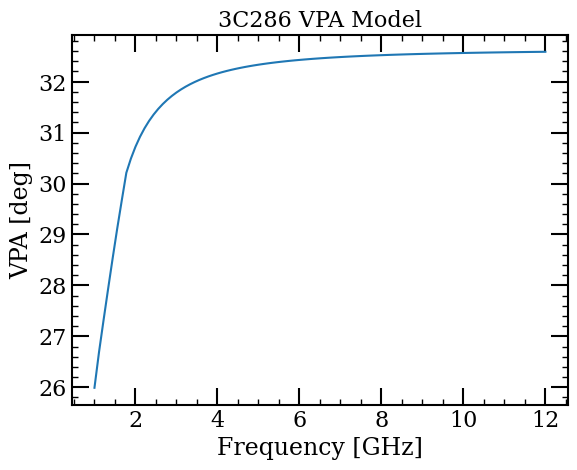

  Spinifex J1331+3030 dates: ['2023-09-04', '2023-09-06', '2023-09-08', '2023-09-16', '2023-09-23', '2023-10-01', '2023-10-06', '2023-10-14', '2023-10-22', '2023-10-28', '2023-11-06', '2023-11-12', '2023-11-18', '2023-11-25', '2024-02-10', '2024-02-19', '2024-02-25', '2024-03-30']

  RM key used: phiPeakPIfit_rm2
  Spinifex source matched: J1331+3030
  Date          RM_fit(rad/m2)  dRM_fit  Spinifex_RM  Spinifex_err  RM_corrected
  --------------------------------------------------------------------------------
  2023-09-04           -4.2752   0.0004      -3.5732        0.1336       -0.7020
  2023-09-06           -4.0032   0.0003      -3.4347        0.1345       -0.5685
  2023-09-08           -4.4719   0.0003      -4.1003        0.1355       -0.3716
  2023-09-16           -5.5432   0.0004      -4.8866        0.1494       -0.6566
  2023-09-23           -5.9199   0.0004      -5.6042        0.1591       -0.3157
  2023-10-01           -6.0580   0.0004      -5.7415        0.1489       -0.31

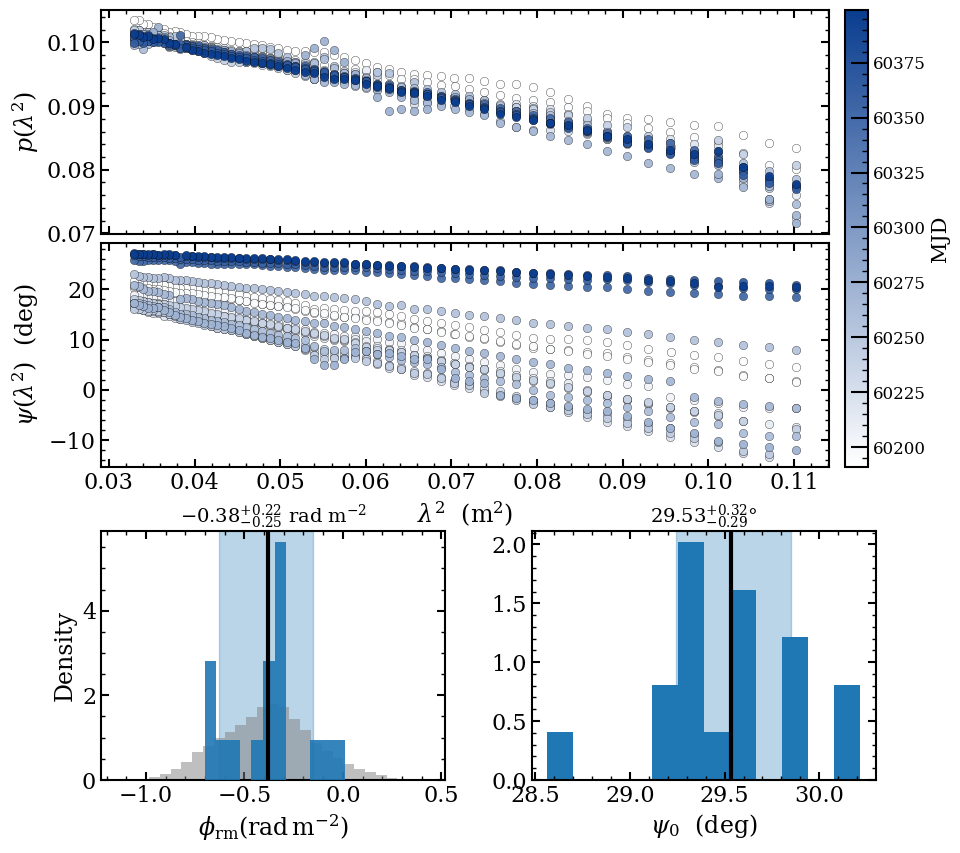

Done.


In [2]:
# =============================================================================
# 3C286 QU-spectrum: ALL epochs, coloured white→blue by MJD
#   Top    : p(λ²)    — MC-propagated errors from I, Q, U
#   Middle : ψ(λ²)    — MC-propagated errors
#   Bottom : Spinifex-corrected RM (left) | ψ₀ + VPA(1.28 GHz) dotted line (right)
# =============================================================================

from matplotlib.colors import LinearSegmentedColormap, Normalize as MplNorm

C_LIGHT     = 2.998e8    # m s⁻¹
N_MC        = 2000       # MC draws  I,Q,U → p and χ
N_MC_POP    = 1000       # populations for RM histogram MC
RM_JSON_KEY = 'phiPeakPIfit_rm2'   # key used to extract fitted Faraday depth

RMSYNTH_3C286_DIR = BASE_DIR / 'publication_work/QU_phenom/rmsynth/3C286'
SPINIFEX_DIR_3C   = BASE_DIR / 'publication_work/QU_phenom/files/spinifex_iono'
SAVE_RM_TABLE     = Path('../plots/results/3C286_spinifex_RM_comparison.txt')

# -------------------------------------------------------------------------
# Helper: VPA model for 3C286
# -------------------------------------------------------------------------
def vpa_deg(nu_ghz):
    """
    Reference VPA [deg] for 3C286.
      nu_ghz ∈ [1.7, 12] : 32.64 − 85.37 · λ²
      nu_ghz  < 1.7       : 29.53 + λ² · (4005.88 · log₁₀(nu)³ − 39.38)
    """
    nu   = np.asarray(nu_ghz, dtype=float)
    lam2 = (C_LIGHT / (nu * 1e9)) ** 2
    return np.where(
        nu >= 1.7,
        32.64 - 85.37 * lam2,
        29.53 + lam2 * (4005.88 * np.log10(nu)**3 - 39.38)
    )

plt.plot(np.linspace(1.0, 12.0, 100), vpa_deg(np.linspace(1.0, 12.0, 100)))
plt.xlabel('Frequency [GHz]')
plt.ylabel('VPA [deg]')
plt.title('3C286 VPA Model')
plt.show()

# -------------------------------------------------------------------------
# Helper: MC error propagation  I, Q, U → p and χ
# -------------------------------------------------------------------------
def mc_propagate_qu(q, u, I, dq, du, dI, n=N_MC, seed=42):
    """Draw n Gaussian realisations and return p_s (nfreq,n) and chi_s (nfreq,n)."""
    rng  = np.random.default_rng(seed)
    q_s  = q[:, None] + dq[:, None] * rng.standard_normal((len(q), n))
    u_s  = u[:, None] + du[:, None] * rng.standard_normal((len(u), n))
    I_s  = I[:, None] + dI[:, None] * rng.standard_normal((len(I), n))
    p_s   = np.sqrt(q_s**2 + u_s**2) / I_s
    chi_s = np.unwrap(0.5 * np.arctan2(u_s, q_s), axis=0)
    return p_s, chi_s

def med_bounds(arr):
    """(median, 16th-pctile, 84th-pctile) for a 1-D array."""
    return np.median(arr), np.percentile(arr, 16), np.percentile(arr, 84)

def load_spinifex_source(filepath, source_name):
    """
    Read a spinifex file and return (rm_vals, rm_err_vals) arrays for
    rows whose Field_Name column exactly matches source_name.
    Each file contains multiple sources; this filters to the right one.
    """
    rm_vals = []
    with open(filepath) as fh:
        for line in fh:
            if line.startswith('#') or not line.strip():
                continue
            parts = line.split()
            if parts[0] == source_name:
                try:
                    rm_vals.append((float(parts[-2]), float(parts[-1])))
                except (ValueError, IndexError):
                    pass
    return np.array(rm_vals) if rm_vals else None

# -------------------------------------------------------------------------
# Load spinifex corrections for J1331+3030 (= 3C286), filtering by name
# Each spinifex file contains multiple sources — we pick J1331+3030 rows only
# -------------------------------------------------------------------------
SPINIFEX_3C286_SOURCE = 'J1331+3030'

spinifex_3c_by_date = {}
for sf in sorted(SPINIFEX_DIR_3C.glob('*.txt')):
    try:
        rows = load_spinifex_source(sf, SPINIFEX_3C286_SOURCE)
        if rows is None:
            continue
        unix_ts = int(sf.name.split('_')[0])
        sf_date = datetime.fromtimestamp(unix_ts, tz=timezone.utc).strftime('%Y-%m-%d')
        spinifex_3c_by_date[sf_date] = (np.median(rows[:, 0]), np.median(rows[:, 1]))
    except Exception as e:
        print(f'  spinifex 3C load error {sf.name}: {e}')

print(f'  Spinifex {SPINIFEX_3C286_SOURCE} dates: {sorted(spinifex_3c_by_date.keys())}')

# -------------------------------------------------------------------------
# Load all 3C286 epoch directories
# -------------------------------------------------------------------------
epochs_3c = []
for epoch_dir in sorted(RMSYNTH_3C286_DIR.iterdir()):
    stem      = epoch_dir.name
    txt_file  = epoch_dir / f'{stem}_rmsynth.txt'
    json_file = epoch_dir / f'{stem}_rmsynth_RMclean.json'
    if not txt_file.exists() or not json_file.exists():
        continue
    dm = re.search(r'(\d{8})', stem)
    if not dm:
        continue
    ds      = dm.group(1)
    iso_str = f'{ds[:4]}-{ds[4:6]}-{ds[6:]}'
    ep_dt   = Time(iso_str, format='iso').datetime

    arr = np.loadtxt(txt_file)
    with open(json_file) as fh:
        j = json.load(fh)

    iono_rm, iono_err = spinifex_3c_by_date.get(iso_str, (np.nan, np.nan))
    has_sf = not np.isnan(iono_rm)

    epochs_3c.append({
        'stem':         stem,
        'date':         ep_dt,
        'iso':          iso_str,
        'mjd':          Time(iso_str, format='iso').mjd,
        'freq':         arr[:, 0],
        'I':  arr[:, 1], 'q':  arr[:, 2], 'u':  arr[:, 3],
        'dI': arr[:, 4], 'dq': arr[:, 5], 'du': arr[:, 6],
        'lam2':         (C_LIGHT / arr[:, 0]) ** 2,
        'rm':           j[RM_JSON_KEY],
        'drm':          j['dPhiPeakPIfit_rm2'],
        'chi0':         j['polAngle0Fit_deg'],
        'dchi0':        j['dPolAngle0Fit_deg'],
        'iono_rm':      iono_rm,
        'iono_err':     iono_err,
        'has_spinifex': has_sf,
    })

epochs_3c.sort(key=lambda e: e['date'])
n_ep = len(epochs_3c)

# -------------------------------------------------------------------------
# Print spinifex summary + save comparison table
# -------------------------------------------------------------------------
hdr = (f'{"Date":<12} {"RM_fit(rad/m2)":>15} {"dRM_fit":>8} '
       f'{"Spinifex_RM":>12} {"Spinifex_err":>13} {"RM_corrected":>13}')
print(f'\n  RM key used: {RM_JSON_KEY}')
print(f'  Spinifex source matched: {SPINIFEX_3C286_SOURCE}')
print(f'  {"="*80}')
print(f'  {hdr}')
print(f'  {"-"*80}')

file_lines = [
    f'# 3C286 fitted Faraday depth vs Spinifex ionospheric RM',
    f'# RM key used to extract fitted depth: {RM_JSON_KEY}',
    f'# Spinifex source matched: {SPINIFEX_3C286_SOURCE}',
    f'# {hdr}',
]

for ep in epochs_3c:
    if ep['has_spinifex']:
        rm_c = ep['rm'] - ep['iono_rm']
        print(f"  {ep['iso']:<12} {ep['rm']:>15.4f} {ep['drm']:>8.4f} "
              f"{ep['iono_rm']:>12.4f} {ep['iono_err']:>13.4f} {rm_c:>13.4f}")
        file_lines.append(
            f"  {ep['iso']}  {ep['rm']:.6f}  {ep['drm']:.6f}  "
            f"{ep['iono_rm']:.6f}  {ep['iono_err']:.6f}  {rm_c:.6f}"
        )
    else:
        print(f"  {ep['iso']:<12} {ep['rm']:>15.4f} {ep['drm']:>8.4f} "
              f"{'--- no spinifex ---':>38}")
        file_lines.append(
            f"  {ep['iso']}  {ep['rm']:.6f}  {ep['drm']:.6f}  NaN  NaN  NaN"
        )

print(f'  {"="*80}\n')
SAVE_RM_TABLE.parent.mkdir(parents=True, exist_ok=True)
SAVE_RM_TABLE.write_text('\n'.join(file_lines) + '\n')
print(f'  Table saved → {SAVE_RM_TABLE}')

# -------------------------------------------------------------------------
# VPA reference at MeerKAT 1.28 GHz
# -------------------------------------------------------------------------
vpa_1500 = float(vpa_deg(1.5))
print(f'  VPA(1.5 GHz) = {vpa_1500:.3f} deg\n')

vpa_1650 = float(vpa_deg(1.65))
print(f'  VPA(1.65 GHz) = {vpa_1650:.3f} deg\n')

# -------------------------------------------------------------------------
# White-to-blue colormap, keyed by MJD
# -------------------------------------------------------------------------
mjd_all    = np.array([e['mjd'] for e in epochs_3c])
wblue_cmap = LinearSegmentedColormap.from_list('wblue', ['#ffffff', '#0a3d8f'])
wblue_norm = MplNorm(vmin=mjd_all.min(), vmax=mjd_all.max())

# Spinifex-corrected values for histograms
corr_eps     = [e for e in epochs_3c if e['has_spinifex']]
rm_corr_vals = np.array([e['rm'] - e['iono_rm'] for e in corr_eps])
chi0_vals    = np.array([e['chi0'] for e in corr_eps])

# -------------------------------------------------------------------------
# MC RM population: 1000 populations, each drawing Gaussian errors on
# both the fitted RM (drm) and the spinifex RM (iono_err) per epoch,
# then coalescing all draws into a single distribution for statistics.
# -------------------------------------------------------------------------
rng_pop = np.random.default_rng(42)
mc_rm_draws = []
for ep in corr_eps:
    rm_s    = ep['rm']      + ep['drm']      * rng_pop.standard_normal(N_MC_POP)
    iono_s  = ep['iono_rm'] + ep['iono_err'] * rng_pop.standard_normal(N_MC_POP)
    mc_rm_draws.append(rm_s - iono_s)
mc_rm_all = np.concatenate(mc_rm_draws)   # shape: (n_epochs * N_MC_POP,)

rm_mc_med, rm_mc_lo, rm_mc_hi = med_bounds(mc_rm_all)
print(f'  RM (MC population, n_epochs={len(corr_eps)}, N_MC_POP={N_MC_POP}): '
      f'{rm_mc_med:.4f} +{rm_mc_hi - rm_mc_med:.4f} / -{rm_mc_med - rm_mc_lo:.4f} rad/m²')

# -------------------------------------------------------------------------
# Figure layout
# -------------------------------------------------------------------------
fig = plt.figure(figsize=(10, 10))
gs_outer = gridspec.GridSpec(2, 1, figure=fig,
                             height_ratios=[2.2, 1.2], hspace=0.18)
gs_top = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_outer[0], hspace=0.04)
ax_p   = fig.add_subplot(gs_top[0])
ax_chi = fig.add_subplot(gs_top[1], sharex=ax_p)
gs_bot  = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_outer[1], wspace=0.25)
ax_rm   = fig.add_subplot(gs_bot[0])
ax_chi0 = fig.add_subplot(gs_bot[1])

# -- Plot each epoch -------------------------------------------------------
for ep in epochs_3c:
    c = wblue_cmap(wblue_norm(ep['mjd']))

    # MC propagation for both p and chi
    p_s, chi_s = mc_propagate_qu(ep['q'], ep['u'], ep['I'],
                                  ep['dq'], ep['du'], ep['dI'])

    p_med = np.median(p_s, axis=1)
    p_lo  = p_med - np.percentile(p_s, 16, axis=1)
    p_hi  = np.percentile(p_s, 84, axis=1) - p_med

    chi_s_deg = np.degrees(chi_s)
    chi_med   = np.median(chi_s_deg, axis=1)
    chi_lo    = chi_med - np.percentile(chi_s_deg, 16, axis=1)
    chi_hi    = np.percentile(chi_s_deg, 84, axis=1) - chi_med

    ax_p.errorbar(ep['lam2'], p_med, yerr=[p_lo, p_hi],
                  fmt='o', ms=6, color=c, lw=0.5, capsize=2, alpha=0.95,
                  markeredgecolor='k', markeredgewidth=0.25, zorder=5)
    ax_chi.errorbar(ep['lam2'], chi_med, yerr=[chi_lo, chi_hi],
                    fmt='o', ms=6, color=c, lw=0.5, capsize=2, alpha=0.95,
                    markeredgecolor='k', markeredgewidth=0.25, zorder=5)

# Colorbar — MJD
sm = plt.cm.ScalarMappable(cmap=wblue_cmap, norm=wblue_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax_p, ax_chi], fraction=0.04, pad=0.02)
cbar.set_label('MJD', fontsize=FONT_LABEL - 2)
cbar.ax.tick_params(labelsize=FONT_TICK - 4)

# Labels (user-edited — do not change)
ax_p.set_ylabel(r'$p(\lambda^2)$')
ax_p.tick_params(labelbottom=False)
ax_chi.set_ylabel(r'$\psi(\lambda^2)$  (deg)')
ax_chi.set_xlabel(r'$\lambda^2$  (m$^2$)')

# -- Bottom left: RM histogram — MC population (grey, back) + raw (C0, front)
bins = np.linspace(mc_rm_all.min(), mc_rm_all.max(), 30)
ax_rm.hist(mc_rm_all, bins=bins, color='grey', edgecolor='none', density=True,
           alpha=0.5, zorder=2)
ax_rm.hist(rm_corr_vals, bins=12, color='C0', edgecolor='none', density=True,
           alpha=0.9, zorder=3)

# Statistics from MC population
ax_rm.axvline(rm_mc_med, color='k', ls='-', lw=3.0, zorder=4)
ax_rm.axvspan(rm_mc_lo, rm_mc_hi, color='C0', alpha=0.3, zorder=1)
ax_rm.set_xlabel(r'$\phi_{\rm rm}  ({\rm rad\,m^{-2}})$')
ax_rm.set_ylabel('Density')
ax_rm.set_title(
    fr'${rm_mc_med:.2f}^{{+{rm_mc_hi - rm_mc_med:.2f}}}_{{-{rm_mc_med - rm_mc_lo:.2f}}}$ rad m$^{{-2}}$',
    fontsize=FONT_TITLE - 2)

# -- Bottom right: ψ₀ histogram + VPA(1.28 GHz) dotted line --------------
ax_chi0.hist(chi0_vals, bins=12, color='C0', edgecolor='none', density=True)
chi0_med_c, chi0_lo_c, chi0_hi_c = med_bounds(chi0_vals)
ax_chi0.axvline(chi0_med_c, color='k', ls='-', lw=3.0)
ax_chi0.axvspan(chi0_lo_c, chi0_hi_c, color='C0', alpha=0.3)
# ax_chi0.axvline(vpa_1500, color='grey', ls='-', lw=2.0)
# ax_chi0.axvline(vpa_1650, color='grey', ls='-', lw=2.0)
# ax_chi0.legend(fontsize=FONT_LEGEND - 5, loc='best')
ax_chi0.set_xlabel(r'$\psi_0$  (deg)')
ax_chi0.set_title(
    fr'${chi0_med_c:.2f}^{{+{chi0_hi_c - chi0_med_c:.2f}}}_{{-{chi0_med_c - chi0_lo_c:.2f}}}$°',
    fontsize=FONT_TITLE - 2)

# Shared tick style
for ax in (ax_p, ax_chi, ax_rm, ax_chi0):
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.tick_params(which='major', length=6)
    ax.tick_params(which='minor', length=3)

fig.align_ylabels([ax_p, ax_chi])
plt.savefig('../plots/results/3C286_QU_diagnostic.pdf', bbox_inches='tight')
plt.show()
print("Done.")


### Polarimetric Properties for J1733-1304

  J1733 epochs loaded: 19
    2023-09-04  RM_peak = -62.390 rad/m²
    2023-09-04  RM_peak = -62.392 rad/m²
    2023-09-04  RM_peak = -61.683 rad/m²
    2023-09-23  RM_peak = -63.694 rad/m²
    2023-09-23  RM_peak = -63.715 rad/m²
    2023-09-23  RM_peak = -63.635 rad/m²
    2023-10-06  RM_peak = -64.993 rad/m²
    2023-10-06  RM_peak = -64.855 rad/m²
    2023-10-06  RM_peak = -64.915 rad/m²
    2023-10-06  RM_peak = -64.597 rad/m²
    2023-10-14  RM_peak = -64.691 rad/m²
    2023-10-14  RM_peak = -64.591 rad/m²
    2023-10-14  RM_peak = -64.752 rad/m²
    2023-10-14  RM_peak = -64.800 rad/m²
    2023-10-16  RM_peak = -64.269 rad/m²
    2023-10-16  RM_peak = -64.733 rad/m²
    2023-10-28  RM_peak = -64.811 rad/m²
    2023-10-28  RM_peak = -64.623 rad/m²
    2023-10-28  RM_peak = -64.931 rad/m²


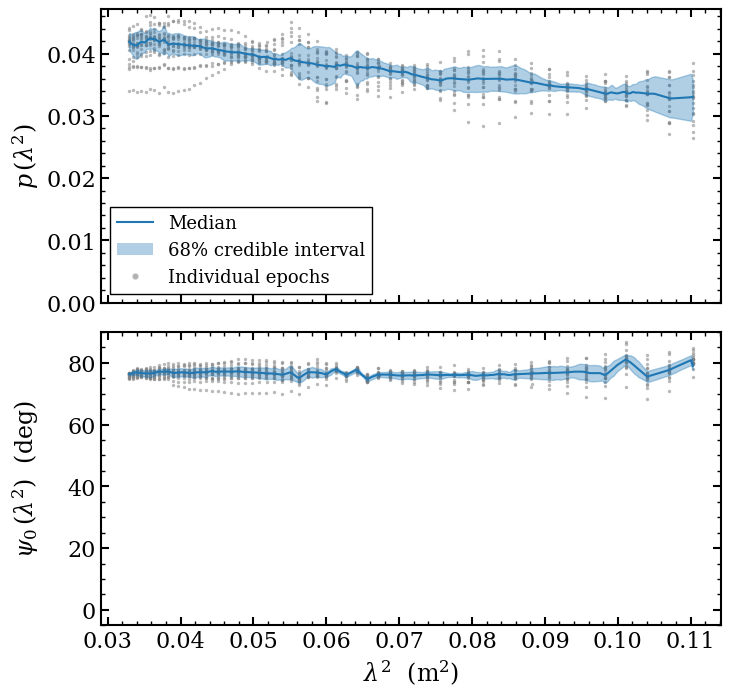

Done.


In [3]:
# =============================================================================
# J1733 QU-spectrum: all epochs combined (per-channel median ± MAD-sigma)
#   Top    : p(λ²)    — per-channel median ± MAD-sigma across all epochs
#   Bottom : ψ₀(λ²)  — same, after peak-RM de-rotation, wrapped to [0°, 90°)
# =============================================================================

RMSYNTH_J1733_DIR = BASE_DIR / 'publication_work/QU_phenom/rmsynth/J1733'
RM_JSON_KEY_J1733 = 'phiPeakPIfit_rm2'

# Toggle: True  → fractional polarisation p(λ²)
#         False → polarisation amplitude PI(λ²) [= p * I]
PLOT_FRAC_POL = True

# -------------------------------------------------------------------------
# Load all J1733 epoch directories
# -------------------------------------------------------------------------
epochs_j1733 = []
for epoch_dir in sorted(RMSYNTH_J1733_DIR.iterdir()):
    stem      = epoch_dir.name
    txt_file  = epoch_dir / f'{stem}_rmsynth.txt'
    json_file = epoch_dir / f'{stem}_rmsynth_RMclean.json'
    if not txt_file.exists() or not json_file.exists():
        continue
    dm = re.search(r'(\d{8})', stem)
    if not dm:
        continue
    ds      = dm.group(1)
    iso_str = f'{ds[:4]}-{ds[4:6]}-{ds[6:]}'
    ep_dt   = Time(iso_str, format='iso').datetime

    arr = np.loadtxt(txt_file)
    with open(json_file) as fh:
        j = json.load(fh)

    epochs_j1733.append({
        'stem': stem,
        'date': ep_dt,
        'iso':  iso_str,
        'mjd':  Time(iso_str, format='iso').mjd,
        'freq': arr[:, 0],
        'I':  arr[:, 1], 'q':  arr[:, 2], 'u':  arr[:, 3],
        'dI': arr[:, 4], 'dq': arr[:, 5], 'du': arr[:, 6],
        'lam2': (C_LIGHT / arr[:, 0]) ** 2,
        'rm':   j[RM_JSON_KEY_J1733],
    })

epochs_j1733.sort(key=lambda e: e['date'])
print(f'  J1733 epochs loaded: {len(epochs_j1733)}')
for ep in epochs_j1733:
    print(f"    {ep['iso']}  RM_peak = {ep['rm']:.3f} rad/m²")

# -------------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------------
def _common_lam2_grid(eps, n_pts=300):
    """Union grid: spans the full range across all epochs."""
    lam2_min = min(ep['lam2'].min() for ep in eps)
    lam2_max = max(ep['lam2'].max() for ep in eps)
    return np.linspace(lam2_min, lam2_max, n_pts)

def _nan_mad_sigma_cols(stack):
    """Per-column MAD-sigma ignoring NaNs (n_epochs × n_chan)."""
    med = np.nanmedian(stack, axis=0)
    return 1.4826 * np.nanmedian(np.abs(stack - med), axis=0)

# -------------------------------------------------------------------------
# Build stacks on the union grid
# -------------------------------------------------------------------------
lam2_common = _common_lam2_grid(epochs_j1733)

p_stack      = []
chi_stack    = []
p_individual   = []   # native-grid values for scatter
chi_individual = []

for ep in epochs_j1733:
    p_s, chi_s = mc_propagate_qu(ep['q'], ep['u'], ep['I'],
                                  ep['dq'], ep['du'], ep['dI'])
    p_med     = np.median(p_s, axis=1)
    chi_s_deg = np.degrees(chi_s) - np.degrees(ep['rm'] * ep['lam2'][:, None])
    chi_s_deg = chi_s_deg % 90
    chi_med   = np.median(chi_s_deg, axis=1)

    if not PLOT_FRAC_POL:
        I_med = np.median(np.tile(ep['I'][:, None], p_s.shape[1]), axis=1)
        p_med = p_med * I_med

    # Store native-grid values for scatter (before interpolation)
    p_individual.append((ep['lam2'], p_med))
    chi_individual.append((ep['lam2'], chi_med))

    # Interpolate onto union grid; NaN outside native coverage
    lam2_ep  = ep['lam2']
    sort_idx = np.argsort(lam2_ep)
    lam2_s   = lam2_ep[sort_idx]
    p_s_sort = p_med[sort_idx]
    chi_s_sort = chi_med[sort_idx]

    p_interp   = np.interp(lam2_common, lam2_s, p_s_sort,
                           left=np.nan, right=np.nan)
    chi_interp = np.interp(lam2_common, lam2_s, chi_s_sort,
                           left=np.nan, right=np.nan)

    p_stack.append(p_interp)
    chi_stack.append(chi_interp)

p_stack   = np.array(p_stack)    # (n_epochs, n_pts), NaN where epoch has no coverage
chi_stack = np.array(chi_stack)

p_med_all   = np.nanmedian(p_stack,   axis=0)
p_sig_all   = _nan_mad_sigma_cols(p_stack)
chi_med_all = np.nanmedian(chi_stack, axis=0)
chi_sig_all = _nan_mad_sigma_cols(chi_stack)

# -------------------------------------------------------------------------
# Figure
# -------------------------------------------------------------------------
fig, (ax_p, ax_chi) = plt.subplots(
    2, 1, figsize=(8, 8), sharex=True,
    gridspec_kw={'hspace': 0.1}
)

# Individual epoch scatter (behind summary)
for lam2_ep, p_ep in p_individual:
    ax_p.scatter(lam2_ep, p_ep, color='grey', alpha=0.55, s=6,
                 linewidths=0, zorder=2)
for lam2_ep, chi_ep in chi_individual:
    ax_chi.scatter(lam2_ep, chi_ep, color='grey', alpha=0.55, s=6,
                   linewidths=0, zorder=2)

# Combined median ± MAD-sigma
ax_p.fill_between(lam2_common, p_med_all - p_sig_all, p_med_all + p_sig_all,
                  color='C0', alpha=0.35, zorder=3)
ax_p.plot(lam2_common, p_med_all, color='C0', lw=1.5, zorder=4)

ax_chi.fill_between(lam2_common, chi_med_all - chi_sig_all, chi_med_all + chi_sig_all,
                    color='C0', alpha=0.35, zorder=3)
ax_chi.plot(lam2_common, chi_med_all, color='C0', lw=1.5, zorder=4)

# Legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='C0', lw=1.5, label='Median'),
    Patch(facecolor='C0', alpha=0.35, edgecolor='none', label='68% credible interval'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
           markersize=5, alpha=0.6, label='Individual epochs'),
]
ax_p.legend(handles=legend_handles, fontsize=FONT_LEGEND - 3, loc='lower left')

p_ylabel = (r'$p\,(\lambda^2)$' if PLOT_FRAC_POL
            else r'$\mathrm{PI}\,(\lambda^2)$  (mJy/beam)')
ax_p.set_ylabel(p_ylabel)
ax_p.tick_params(labelbottom=False)
ax_p.set_ylim(bottom=0)

ax_chi.set_ylabel(r'$\psi_{0}\,(\lambda^2)$  (deg)')
ax_chi.set_xlabel(r'$\lambda^2$  (m$^2$)')
ax_chi.set_ylim(-5, 90)

for ax in (ax_p, ax_chi):
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.tick_params(which='major', length=6)
    ax.tick_params(which='minor', length=3)

fig.align_ylabels([ax_p, ax_chi])
plt.savefig('../plots/results/J1733_QU_diagnostic.pdf', bbox_inches='tight')
plt.show()
print("Done.")

### Faraday dispersion function manipulation of the Target Swift J1727

Loading radio CSV...
  LC: 15 MeerKAT points, 169 other-telescope points
Loading spinifex corrections...
  Spinifex: 19 dates loaded
Loading RMclean epoch data...
  RMclean: 18 epochs loaded
  χ²_red = 11.642  (inflation ×3.412)
  Weighted mean (n=15): -0.4819 ± 0.5628 rad/m²
  Linear fit: a = -0.6106 ± 0.5681 rad/m²  b = -0.01843 ± 0.01108 rad/m²/day


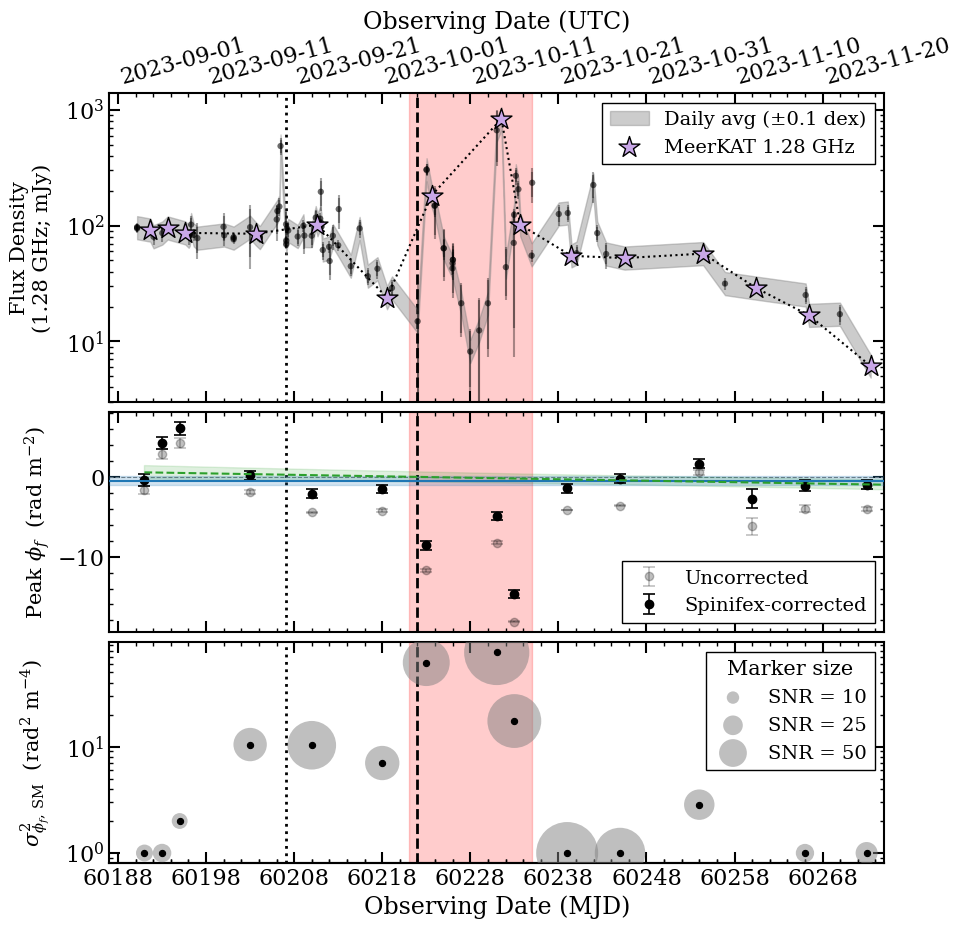

Done.


In [4]:
# =============================================================================
# 3-PANEL: FLUX DENSITY  /  FARADAY DEPTH  /  SECOND MOMENT  vs epoch
# =============================================================================
# Self-contained cell. All configuration in the globals section below.
# Panel 1 : Radio flux density at 1.28 GHz (log scale)
# Panel 2 : Peak Faraday depth — uncorrected + spinifex-corrected RM
# Panel 3 : Second moment of the CLEANed FDF (log scale)


# =============================================================================
# GLOBALS
# =============================================================================

BASE_DIR     = Path('/home/andrewhughes/Projects/X-KAT/SwiftJ1727/new_meerkat/SpectroPol')
LC_DIR       = Path('/home/andrewhughes/Projects/X-KAT/SwiftJ1727/new_meerkat/SpectroPol'
                    '/plotting_and_analysis/files/LC_files')
RADIO_CSV    = LC_DIR / 'SW1727_Radio.csv'
RMSYNTH_DIR  = BASE_DIR / 'publication_work/QU_phenom/rmsynth/J1727'
SPINIFEX_DIR = BASE_DIR / 'publication_work/QU_phenom/files/spinifex_iono'

SAVE_PATH = '../plots/results/results_faraday_moments.pdf'

# --- Time range --------------------------------------------------------------
LC_START    = '2023-09-01T00:00:00'
LC_END      = '2023-11-26T00:00:00'
CUTOFF_DATE = datetime(2024, 3, 1)
RED_START   = datetime(2023, 10, 4)
RED_END     = datetime(2023, 10, 18)

# --- State-transition vertical lines -----------------------------------------
TRANSITION_DATES = Time([60222, 60389], format='mjd').datetime  # dashed, dotted
HIGHLIGHT_SEP20  = Time('2023-09-20T01:00:00', format='isot').datetime  # dashed

# --- Flux / LC globals -------------------------------------------------------
MEERKAT_FREQ_GHZ    = 1.28
SMOOTH_GROUP_WINDOW = 0.1
SMOOTH_LOG_WIDTH    = 0.10
SMOOTH_CUTOFF       = '2023-11-26T00:00:00'
SMOOTH_COLOR        = 'grey'
SMOOTH_ALPHA        = 0.4

MK_COLOR   = '#C9A7E8'
MK_EDGE    = 'k'
MK_MARKER  = '*'
MK_SIZE    = 250

OTHER_COLOR = 'k'
OTHER_ALPHA = 0.35
OTHER_SIZE  = 20

N_MC                   = 500
ALPHA_TIME_WINDOW_DAYS = 1.0 / 1440.0
ALPHA_CLIP_DRY_RUN     = True

# --- RM / second moment globals ----------------------------------------------
RM_JSON_KEY_J1727     = 'phiPeakPIfit_rm2'
SPINIFEX_J1727_SOURCE = 'SwiftJ1727'
SPINIFEX_OFFSET       = -0.3
SPINIFEX_SYS_ERR      = 0.5

SNR_MARKER_SCALE  = 8.0
SNR_MARKER_MIN    = 20
DATA_MARKER_SIZE  = 20

INFLATE_TO_CHI2 = True
PLOT_LINEAR_FIT = True

# --- Figure layout -----------------------------------------------------------
FIG_SIZE      = (10, 10)
HSPACE        = 0.04
HEIGHT_RATIOS = [1.4, 1, 1]
LC_TICK_INTERVAL = 10

# --- Fonts -------------------------------------------------------------------
FONT_YLABEL       = 15
FONT_LEGEND       = 14
FONT_LEGEND_TITLE = 15

plt.rcParams.update({
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':    'dejavuserif',
    'axes.linewidth':      1.5,
    'xtick.direction':     'in',  'ytick.direction':     'in',
    'xtick.top':           True,  'ytick.right':         True,
    'xtick.minor.visible': True,  'ytick.minor.visible': True,
    'xtick.major.size':    8,     'ytick.major.size':    8,
    'xtick.minor.size':    3,     'ytick.minor.size':    3,
})

# FormatAxis, plot2mjd, mjd2plot assumed to be defined in scope.


# =============================================================================
# DATA LOADING — LIGHTCURVE
# =============================================================================

print('Loading radio CSV...')
start_datetime = Time(LC_START, format='isot').datetime
end_datetime   = Time(LC_END,   format='isot').datetime

big_data = pd.read_csv(RADIO_CSV)
big_data['Midpoint (DT)'] = Time(big_data['Midpoint (MJD)'], format='mjd').datetime
big_data = (big_data[(big_data['Frequency (GHz)'] >= 1.0) &
                     (big_data['Frequency (GHz)'] <= 15.0)]
            .reset_index(drop=True))

# Spectral-index fitting for flux extrapolation
row_alpha     = np.full(len(big_data), np.nan)
row_alpha_err = np.full(len(big_data), np.nan)
non_mk_tmp    = big_data[big_data['Telescope'].isin(['VLA', 'ATCA', 'ATA'])].copy()

for tele_g, tele_grp in non_mk_tmp.groupby('Telescope'):
    tele_grp  = tele_grp.sort_values('Midpoint (MJD)')
    mjds      = tele_grp['Midpoint (MJD)'].values
    sim_group = np.concatenate([[0], np.cumsum(np.diff(mjds) > ALPHA_TIME_WINDOW_DAYS)])
    tele_grp  = tele_grp.copy()
    tele_grp['sim_group'] = sim_group

    for gid, grp in tele_grp.groupby('sim_group'):
        if grp['Frequency (GHz)'].nunique() < 2:
            continue
        nu  = grp['Frequency (GHz)'].values.astype(float)
        S   = grp['Integrated flux (mJy)'].values.astype(float)
        dS  = np.sqrt(grp['Error (mJy)'].values.astype(float)**2 + (0.03 * S)**2)
        w   = S / dS
        try:
            a_fit = float(np.polyfit(np.log(nu), np.log(S), 1, w=w)[0])
        except (np.linalg.LinAlgError, ValueError):
            continue
        rng = np.random.default_rng(seed=int(grp['Midpoint (MJD)'].iloc[0] * 1440) % (2**31))
        mc_alphas = []
        for _ in range(N_MC):
            S_mc = S + dS * rng.standard_normal(len(S))
            if np.any(S_mc <= 0):
                continue
            try:
                mc_alphas.append(float(np.polyfit(np.log(nu), np.log(S_mc), 1, w=w)[0]))
            except (np.linalg.LinAlgError, ValueError):
                continue
        if len(mc_alphas) < N_MC // 2:
            continue
        row_alpha[grp.index]     = a_fit
        row_alpha_err[grp.index] = float(np.std(mc_alphas))

# Extrapolate all fluxes to 1.28 GHz
is_mk_1p28      = ((big_data['Telescope'] == 'MeerKAT') &
                   (big_data['Frequency (GHz)'] == MEERKAT_FREQ_GHZ)).values
has_alpha       = ~np.isnan(row_alpha)
valid           = is_mk_1p28 | has_alpha
alpha_for_scale = np.where(is_mk_1p28, 0.0, row_alpha)
scale           = (MEERKAT_FREQ_GHZ / big_data['Frequency (GHz)'].values) ** alpha_for_scale
ln_ratio        = np.log(MEERKAT_FREQ_GHZ / big_data['Frequency (GHz)'].values)
alpha_err_prop  = np.where(is_mk_1p28, 0.0, row_alpha_err)
S_obs           = big_data['Integrated flux (mJy)'].values
dS_obs          = big_data['Error (mJy)'].values

big_data['flux_1p28'] = np.where(valid, S_obs * scale, np.nan)
big_data['err_1p28']  = np.where(
    valid,
    np.abs(scale) * np.sqrt(dS_obs**2 + (S_obs * ln_ratio * alpha_err_prop)**2),
    np.nan,
)

# Smoothed flux band
time_mask   = ((big_data['Midpoint (DT)'] >= start_datetime) &
               (big_data['Midpoint (DT)'] <= end_datetime))
mk_non_ref  = ((big_data['Telescope'] == 'MeerKAT') &
               (big_data['Frequency (GHz)'] != MEERKAT_FREQ_GHZ))
smooth_pool = (big_data[big_data['Telescope'].isin(['VLA', 'MeerKAT', 'ATCA', 'ATA'])
                        & time_mask & ~mk_non_ref]
               .sort_values('Midpoint (MJD)').copy())
cutoff_dt   = Time(SMOOTH_CUTOFF, format='isot').datetime

smoothed_times, smoothed_flux = [], []
used_mask = np.zeros(len(smooth_pool), dtype=bool)
for i in range(len(smooth_pool)):
    if used_mask[i] or smooth_pool['Midpoint (DT)'].iloc[i] > cutoff_dt:
        continue
    current_mjd = smooth_pool.iloc[i]['Midpoint (MJD)']
    group_mask  = np.abs(smooth_pool['Midpoint (MJD)'] - current_mjd) <= SMOOTH_GROUP_WINDOW
    group       = smooth_pool[group_mask].dropna(subset=['flux_1p28', 'err_1p28'])
    if len(group) == 0:
        used_mask[group_mask.values] = True
        continue
    weights = 1.0 / (group['err_1p28']**2 + 1e-10)
    smoothed_flux.append(np.average(group['flux_1p28'], weights=weights))
    smoothed_times.append(
        Time(np.average(group['Midpoint (MJD)'], weights=weights), format='mjd').datetime)
    used_mask[group_mask.values] = True

smoothed_times = np.array(smoothed_times)
smoothed_flux  = np.array(smoothed_flux)

other_data = big_data[big_data['Telescope'].isin(['VLA', 'ATCA', 'ATA']) & time_mask]
mk_data    = big_data[(big_data['Telescope'] == 'MeerKAT') &
                      (big_data['Frequency (GHz)'] == MEERKAT_FREQ_GHZ) & time_mask]

print(f'  LC: {len(mk_data)} MeerKAT points, {len(other_data)} other-telescope points')

# =============================================================================
# DATA LOADING — SPINIFEX IONOSPHERIC CORRECTIONS
# =============================================================================

print('Loading spinifex corrections...')
spinifex_by_date = {}
for sf in sorted(SPINIFEX_DIR.glob('*.txt')):
    try:
        rows = []
        with open(sf) as fh:
            for line in fh:
                if line.startswith('#') or not line.strip():
                    continue
                parts = line.split()
                if parts[0] == SPINIFEX_J1727_SOURCE:
                    try:
                        rows.append((float(parts[-2]), float(parts[-1])))
                    except (ValueError, IndexError):
                        pass
        if not rows:
            continue
        rows    = np.array(rows)
        unix_ts = int(sf.name.split('_')[0])
        sf_date = datetime.fromtimestamp(unix_ts, tz=timezone.utc).strftime('%Y-%m-%d')
        spinifex_by_date[sf_date] = (np.median(rows[:, 0]), np.median(rows[:, 1]))
    except Exception as e:
        print(f'  spinifex load error {sf.name}: {e}')

print(f'  Spinifex: {len(spinifex_by_date)} dates loaded')

# =============================================================================
# DATA LOADING — RMCLEAN EPOCHS
# =============================================================================

print('Loading RMclean epoch data...')
epoch_dates   = []
peak_phi      = []
dpeak_phi     = []
second_moment = []
snr_vals      = []

for epoch_dir in sorted(p for p in RMSYNTH_DIR.iterdir() if '-t00' not in p.name):
    stem = epoch_dir.name
    if '_ejecta' in stem:
        continue
    json_file = epoch_dir / f'{stem}_rmsynth_RMclean.json'
    if not json_file.exists():
        print(f'  missing JSON: {stem}')
        continue
    date_match = re.search(r'(\d{8})', stem)
    if not date_match:
        print(f'  cannot parse date: {stem}')
        continue
    date_str = date_match.group(1)
    iso_str  = f'{date_str[:4]}-{date_str[4:6]}-{date_str[6:]}'
    epoch_dt = Time(iso_str, format='iso').datetime
    if epoch_dt > CUTOFF_DATE:
        continue
    epoch_dates.append(epoch_dt)
    with open(json_file) as f:
        j = json.load(f)
    peak_phi.append(j[RM_JSON_KEY_J1727])
    dpeak_phi.append(j['dPhiObserved_rm2'])
    second_moment.append(j['mom2CCFDF'])
    snr_vals.append(j['snrPIfit'] * j['dAmpObserved'] / j['dAmpPeakPIfit'])

order         = sorted(range(len(epoch_dates)), key=lambda i: epoch_dates[i])
epoch_dates   = [epoch_dates[i]   for i in order]
peak_phi      = np.array([peak_phi[i]      for i in order])
dpeak_phi     = np.array([dpeak_phi[i]     for i in order])
second_moment = np.array([second_moment[i] for i in order])
snr_vals      = np.array([snr_vals[i]      for i in order])

second_moment = np.where(second_moment < 1.0, 1.0, second_moment)
marker_sizes  = np.clip(snr_vals * SNR_MARKER_SCALE, SNR_MARKER_MIN, None)
mjd_epoch     = np.array([Time(d).mjd for d in epoch_dates])

print(f'  RMclean: {len(epoch_dates)} epochs loaded')

# =============================================================================
# SPINIFEX CORRECTIONS + STATISTICS
# =============================================================================

peak_phi_corr  = np.full_like(peak_phi, np.nan)
dpeak_phi_corr = np.full_like(dpeak_phi, np.nan)
has_corr       = np.zeros(len(epoch_dates), dtype=bool)

for i, dt in enumerate(epoch_dates):
    key = dt.strftime('%Y-%m-%d')
    if key in spinifex_by_date:
        iono_rm, iono_err  = spinifex_by_date[key]
        peak_phi_corr[i]   = peak_phi[i] - iono_rm + SPINIFEX_OFFSET
        dpeak_phi_corr[i]  = np.sqrt(dpeak_phi[i]**2 + iono_err**2 + SPINIFEX_SYS_ERR**2)
        has_corr[i]        = True

outside_red = np.array([
    has_corr[i] and not (RED_START <= epoch_dates[i] <= RED_END)
    for i in range(len(epoch_dates))
])
x_out = peak_phi_corr[outside_red]
s_out = dpeak_phi_corr[outside_red]
n_out = int(outside_red.sum())

w           = 1.0 / s_out**2
wm_phi      = np.sum(w * x_out) / np.sum(w)
wm_err      = 1.0 / np.sqrt(np.sum(w))
chi2_red    = np.sum(w * (x_out - wm_phi)**2) / (n_out - 1)
scale_infl  = np.sqrt(max(chi2_red, 1.0))
wm_err_infl = wm_err * scale_infl
wm_err_f    = wm_err_infl if INFLATE_TO_CHI2 else wm_err

print(f'  χ²_red = {chi2_red:.3f}  (inflation ×{scale_infl:.3f})')
print(f'  Weighted mean (n={n_out}): {wm_phi:.4f} ± {wm_err_f:.4f} rad/m²')

t_out  = mjd_epoch[outside_red]
t_ref  = t_out.mean()
dt_out = t_out - t_ref
A      = np.column_stack([np.ones(n_out), dt_out])
w_vec  = 1.0 / s_out**2
AtW    = A.T * w_vec
AtWA   = AtW @ A
AtWy   = AtW @ x_out
theta  = np.linalg.solve(AtWA, AtWy)
cov    = np.linalg.inv(AtWA)
a_fit, b_fit   = theta
da_raw, db_raw = np.sqrt(cov[0, 0]), np.sqrt(cov[1, 1])
da_infl = da_raw * scale_infl
db_infl = db_raw * scale_infl

print(f'  Linear fit: a = {a_fit:.4f} ± {da_infl:.4f} rad/m²  '
      f'b = {b_fit:.5f} ± {db_infl:.5f} rad/m²/day')

mjd_range = np.array([Time(start_datetime).mjd, Time(end_datetime).mjd])

# =============================================================================
# FIGURE
# =============================================================================

fig, (ax_lc, ax_rm, ax_sm) = plt.subplots(
    3, 1,
    figsize=FIG_SIZE,
    sharex=True,
    gridspec_kw={'hspace': HSPACE, 'height_ratios': HEIGHT_RATIOS},
)

# --- Panel 1: Flux density ---------------------------------------------------
if len(smoothed_flux) > 1:
    ax_lc.fill_between(
        smoothed_times,
        smoothed_flux / 10**SMOOTH_LOG_WIDTH,
        smoothed_flux * 10**SMOOTH_LOG_WIDTH,
        color=SMOOTH_COLOR, alpha=SMOOTH_ALPHA, zorder=1,
        label=f'Daily avg (\u00b1{SMOOTH_LOG_WIDTH} dex)',
    )

ax_lc.scatter(other_data['Midpoint (DT)'], other_data['flux_1p28'],
              marker='o', s=OTHER_SIZE, color=OTHER_COLOR,
              alpha=OTHER_ALPHA, ec='none', zorder=500)
ax_lc.errorbar(other_data['Midpoint (DT)'], other_data['flux_1p28'],
               other_data['err_1p28'],
               fmt='none', ecolor='k', alpha=OTHER_ALPHA, zorder=400)

ax_lc.scatter(mk_data['Midpoint (DT)'], mk_data['flux_1p28'],
              marker=MK_MARKER, s=MK_SIZE, color=MK_COLOR,
              ec=MK_EDGE, zorder=10000, label='MeerKAT 1.28 GHz')
ax_lc.plot(mk_data['Midpoint (DT)'], mk_data['flux_1p28'],
           ls=':', lw=1.5, color='k', zorder=5000)

ax_lc.set_yscale('log')
ax_lc.set_ylabel('Flux Density\n(1.28 GHz; mJy)', fontsize=FONT_YLABEL)
ax_lc.set_ylim(3, 1.4e3)
ax_lc.legend(fontsize=FONT_LEGEND, loc='upper right')

# --- Panel 2: Peak Faraday depth ---------------------------------------------
ax_rm.errorbar(
    epoch_dates, peak_phi, yerr=dpeak_phi,
    fmt='o', color='k', ms=6, capsize=4, capthick=1.2, lw=1.2,
    alpha=0.25, zorder=4, label='Uncorrected',
)
if has_corr.any():
    corr_dates = [epoch_dates[i] for i in range(len(epoch_dates)) if has_corr[i]]
    ax_rm.errorbar(
        corr_dates, peak_phi_corr[has_corr], yerr=dpeak_phi_corr[has_corr],
        fmt='o', color='k', ms=6, capsize=4, capthick=1.2, lw=1.2,
        zorder=5, label='Spinifex-corrected',
    )
ax_rm.axhline(0, color='grey', lw=0.8, ls='--')
ax_rm.axhline(wm_phi, color='C0', lw=1.5, ls='-', zorder=6)
ax_rm.axhspan(wm_phi - wm_err_f, wm_phi + wm_err_f, color='C0', alpha=0.2, zorder=3)

if PLOT_LINEAR_FIT:
    fit_mjd   = np.linspace(mjd_epoch[outside_red].min(), mjd_epoch[outside_red].max(), 200)
    fit_rm    = a_fit + b_fit * (fit_mjd - t_ref)
    fit_dates = [Time(m, format='mjd').datetime for m in fit_mjd]
    fit_err   = np.sqrt(cov[0, 0] + (fit_mjd - t_ref)**2 * cov[1, 1]
                        + 2 * (fit_mjd - t_ref) * cov[0, 1])
    if INFLATE_TO_CHI2:
        fit_err = fit_err * scale_infl
    ax_rm.plot(fit_dates, fit_rm, color='C2', lw=1.5, ls='--', zorder=7)
    ax_rm.fill_between(fit_dates, fit_rm - fit_err, fit_rm + fit_err,
                       color='C2', alpha=0.15, zorder=2)

ax_rm.set_ylabel(r'Peak $\phi_f$  (rad m$^{-2}$)', fontsize=FONT_YLABEL)
ax_rm.legend(fontsize=FONT_LEGEND, loc='lower right')

# --- Panel 3: Second moment --------------------------------------------------
ax_sm.scatter(epoch_dates, second_moment,
              s=marker_sizes, color='grey', alpha=0.5, edgecolors='none', zorder=4)
ax_sm.scatter(epoch_dates, second_moment,
              s=DATA_MARKER_SIZE, color='k', edgecolors='k', linewidths=0.8, zorder=5)
ax_sm.set_yscale('log')
ax_sm.set_ylabel(r'$\sigma^2_{\phi_f,\,\mathrm{SM}}$  (rad$^2$ m$^{-4}$)', fontsize=FONT_YLABEL)

for snr_ref in [10, 25, 50]:
    ax_sm.scatter([], [], s=np.clip(snr_ref * SNR_MARKER_SCALE, SNR_MARKER_MIN, None),
                  color='grey', alpha=0.5, edgecolors='none', label=f'SNR = {snr_ref}')
ax_sm.legend(title='Marker size', fontsize=FONT_LEGEND,
             title_fontsize=FONT_LEGEND_TITLE, loc='upper right')

# --- Red region + vertical lines on all panels -------------------------------
for ax in (ax_lc, ax_rm, ax_sm):
    ax.axvspan(RED_START, RED_END, color='red', alpha=0.2, zorder=0)
    if start_datetime <= TRANSITION_DATES[0] <= end_datetime:
        ax.axvline(TRANSITION_DATES[0], ls='--', c='k', lw=2.0, zorder=0)
    if start_datetime <= TRANSITION_DATES[1] <= end_datetime:
        ax.axvline(TRANSITION_DATES[1], ls=':', c='k', lw=2.0, zorder=0)
    if start_datetime <= HIGHLIGHT_SEP20 <= end_datetime:
        ax.axvline(HIGHLIGHT_SEP20, ls=':', c='k', lw=2.0, zorder=0)

# --- Shared axis formatting --------------------------------------------------
FormatAxis(np.array([ax_lc, ax_rm, ax_sm]), mjd=mjd_range, interval=LC_TICK_INTERVAL, dt=1)
ax_sm.tick_params(labelbottom=False)

fig.align_ylabels([ax_lc, ax_rm, ax_sm])
plt.savefig(SAVE_PATH, bbox_inches='tight')
plt.show()
print('Done.')

# Massive panel of FDF plots

18
Saved → ../plots/results/results_FDF_panels.pdf


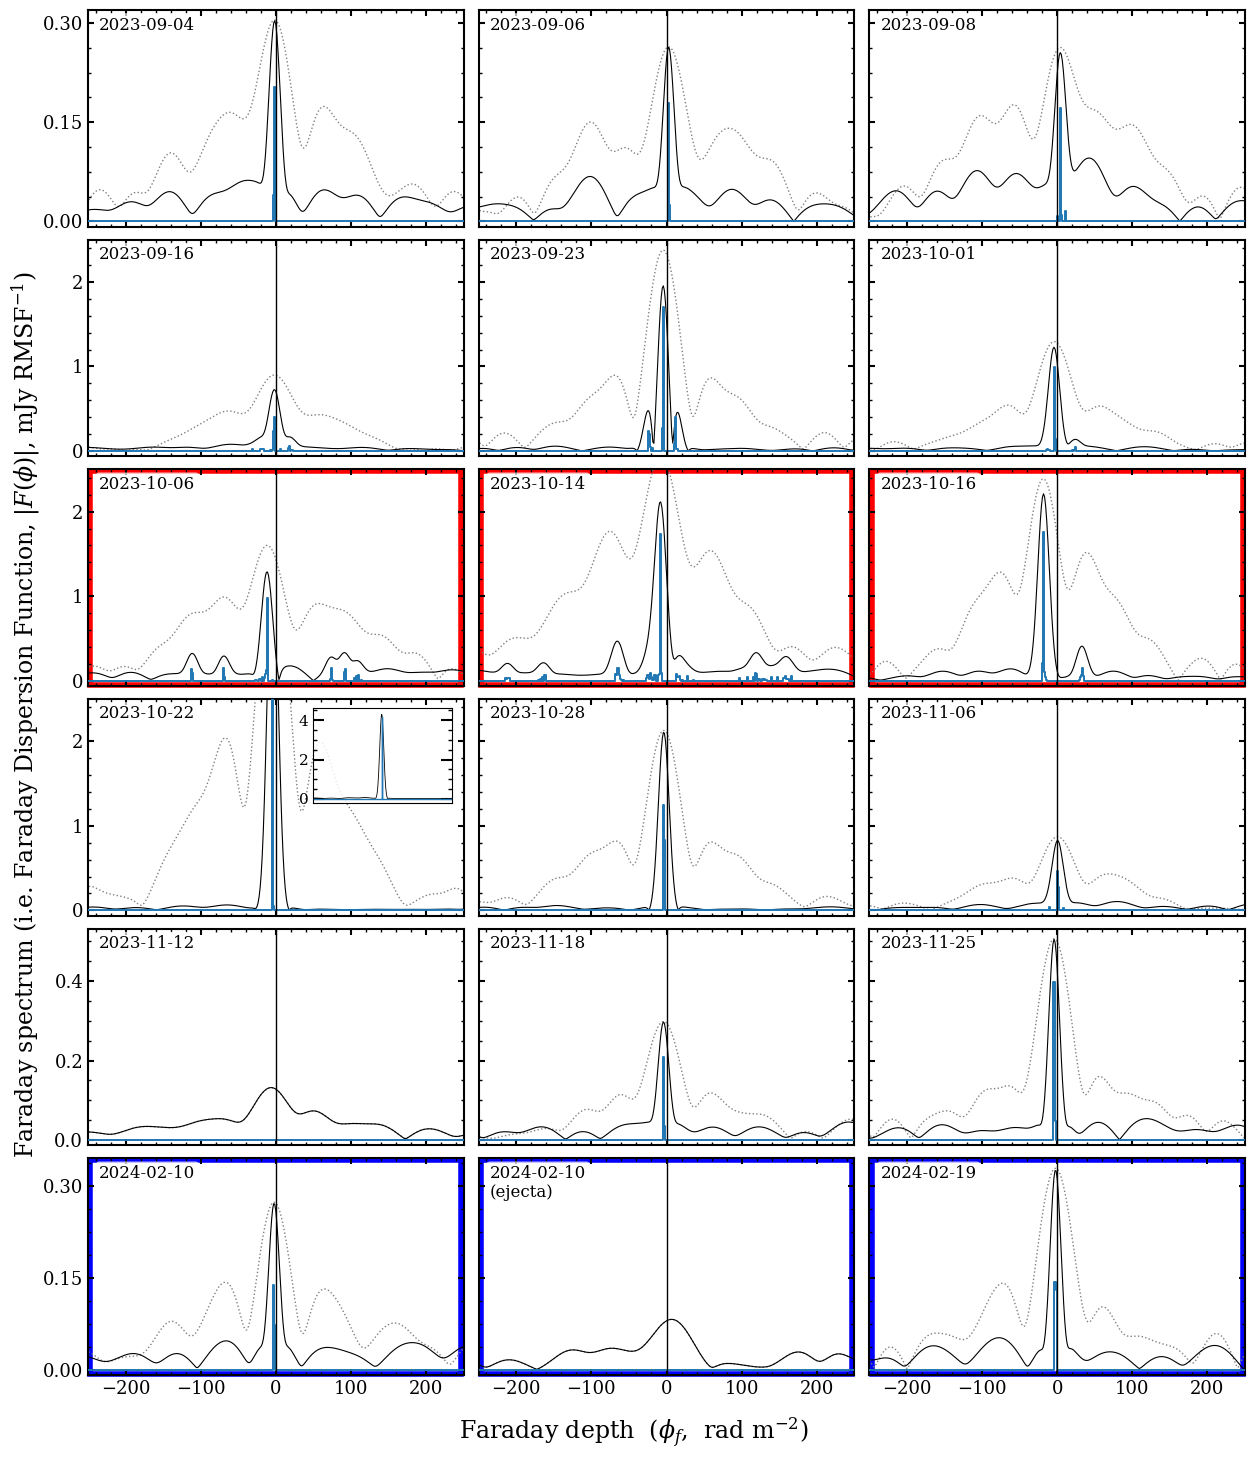

In [5]:
# Modify this path to point to the directory containing the RMclean JSON files for J1727.
# Get file names prefixes:
FDF_PREFIXES = ['publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_WAPITI_20230904',
                'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_QU_20230906',
                'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_QU_20230908',
                'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_QU_20230916',
                'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_WAPITI_20230923',
                'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_QU_20231001',
                'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_WAPITI_20231006',
                #'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_WAPITI_20231006_t0000', # Comment this out
                #'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_WAPITI_20231006_t0001', # Comment this out
                'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_WAPITI_20231014',
                'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_WAPITI_20231016',
                'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_QU_20231022',
                'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_QU_20231028',
                'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_QU_20231106',
                'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_QU_20231112',
                'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_QU_20231118',
                'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_QU_20231125',
                'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_QU_20240210',
                'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_QU_20240210_ejecta',
                'publication_work/QU_phenom/rmsynth/J1727/SwiftJ1727_QU_20240219']
print(len(FDF_PREFIXES))

def plot_all_fdfs(fdf_prefixes, phi_lim=250, n_cols=3,
                  fdf_color='k', cc_color='C0',
                  save_path=None):
    """
    Grid of clean FDF amplitude panels.

    Panels are filled left-to-right, row by row, strictly in the order
    of fdf_prefixes.  File paths are resolved as BASE_DIR / prefix.
    """

    n_epochs = len(fdf_prefixes)
    n_rows   = int(np.ceil(n_epochs / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(13.0, n_rows * 2.5),
        sharex=True,
    )
    axes_flat = np.array(axes).flatten()   # row-major: [row0col0, row0col1, ...]

    for i, prefix in enumerate(fdf_prefixes):
        ax         = axes_flat[i]
        epoch_dir  = BASE_DIR / prefix
        stem       = epoch_dir.name

        fdf_file = epoch_dir / f'{stem}_rmsynth_FDFclean.dat'
        cc_file  = epoch_dir / f'{stem}_rmsynth_FDFmodel.dat'

        if not fdf_file.exists():
            print(f'  missing FDFclean: {stem}')
            ax.set_visible(False)
            continue

        # Parse date and flags from stem
        date_match = re.search(r'(\d{8})', stem)
        iso_date   = ''
        if date_match:
            d = date_match.group(1)
            iso_date = f'{d[:4]}-{d[4:6]}-{d[6:]}'
        is_ejecta  = '_ejecta' in stem

        # Spine colour by epoch period (priority: solid red > translucent red > translucent blue)
        if '2023-10-06' <= iso_date <= '2023-10-16':
            _bc, _ba, _blw = 'red', 1.0, 4
        #elif '2023-09-16' <= iso_date <= '2023-10-22':
        #    _bc, _ba, _blw = 'red', 0.5, 2
        elif iso_date.startswith('2024-'):
            _bc, _ba, _blw = 'blue', 1.0, 4
        else:
            _bc, _ba, _blw = None, 0.0, 0

        # FDF amplitude (mJy)
        fdf     = np.loadtxt(fdf_file)
        phi     = fdf[:, 0]
        fdf_amp = np.sqrt(fdf[:, 1]**2 + fdf[:, 2]**2) * 1e3
        mask    = np.abs(phi) <= phi_lim
        ax.plot(phi[mask], fdf_amp[mask], color=fdf_color, lw=0.8, zorder=3)

        # Dirty FDF as dotted line (mJy)
        dirty_file = epoch_dir / f'{stem}_rmsynth_FDFdirty.dat'
        if dirty_file.exists():
            dirty     = np.loadtxt(dirty_file)
            dirty_amp = np.sqrt(dirty[:, 1]**2 + dirty[:, 2]**2) * 1e3
            ax.plot(phi[mask], dirty_amp[mask], color='grey', lw=1.0, ls=':', zorder=2)

        # Clean components — centre-aligned step function (mJy)
        if cc_file.exists():
            cc      = np.loadtxt(cc_file)
            cc_phi  = cc[:, 0]
            cc_amp  = np.sqrt(cc[:, 1]**2 + cc[:, 2]**2) * 1e3
            cc_mask = np.abs(cc_phi) <= phi_lim
            ax.step(cc_phi[cc_mask], cc_amp[cc_mask],
                    where='mid', color=cc_color, lw=1.4, zorder=4)

        # Date annotation top-left
        label = iso_date
        if is_ejecta:
            label += '\n(ejecta)'
        ax.text(0.03, 0.97, label,
                transform=ax.transAxes,
                fontsize=12, va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))

        ax.axvline(0, color='k', lw=1.0, ls='-', zorder=1000)
        ax.set_xlim(-phi_lim, phi_lim)
        ax.tick_params(which='both', direction='in', top=True, right=True,
                       labelsize=FONT_TICK - 3)
        ax.tick_params(which='major', length=4)
        ax.tick_params(which='minor', length=2)
        ax.yaxis.set_major_locator(plt.MaxNLocator(3, prune='both'))
        # Inset for 2023-10-22: full natural y-range in top-right, y-axis only
        if iso_date == '2023-10-22':
            _nat_max = fdf_amp[mask].max()
            axins = ax.inset_axes([0.60, 0.52, 0.37, 0.44])
            axins.plot(phi[mask], fdf_amp[mask], color=fdf_color, lw=0.6, zorder=3)
            if cc_file.exists():
                _cci     = np.loadtxt(cc_file)
                _ccm     = np.abs(_cci[:, 0]) <= phi_lim
                _cc_amp_i = np.sqrt(_cci[:, 1]**2 + _cci[:, 2]**2) * 1e3
                axins.step(_cci[_ccm, 0], _cc_amp_i[_ccm],
                           where='mid', color=cc_color, lw=1.0, zorder=4)
            axins.set_xlim(-phi_lim, phi_lim)
            axins.set_ylim(-0.05 * _nat_max, _nat_max * 1.08)
            axins.set_xticks([])
            for _sp in axins.spines.values():
                _sp.set_visible(True)
                _sp.set_linewidth(0.8)
            axins.patch.set_alpha(0.85)
            axins.tick_params(which='both', direction='in', left=True, right=True,
                              bottom=False, top=False, labelsize=FONT_TICK - 5)
            axins.yaxis.set_major_locator(plt.MaxNLocator(3, prune='both'))

        if _bc:
            from matplotlib.patches import Rectangle
            _rect = Rectangle((0.006, 0.006), 0.988, 0.988,
                               transform=ax.transAxes, clip_on=False,
                               fill=False, edgecolor=_bc, lw=_blw,
                               linestyle='-', alpha=_ba, zorder=0.5)
            ax.add_patch(_rect)

    # Top 4 rows share one y-scale; remaining rows equalise per-row
    _shared = [r for r in [1, 2, 3] if r < n_rows]
    _shared_axes = [axes_flat[r * n_cols + c]
                    for r in _shared for c in range(n_cols)
                    if (r * n_cols + c) < n_epochs
                    and axes_flat[r * n_cols + c].get_visible()]
    _shared_ymax = min(max(ax.get_ylim()[1] for ax in _shared_axes) if _shared_axes else 0, 2.5)

    for r in range(n_rows):
        row_axes = [axes_flat[r * n_cols + c] for c in range(n_cols)
                    if (r * n_cols + c) < n_epochs
                    and axes_flat[r * n_cols + c].get_visible()]
        if not row_axes:
            continue
        ymax = _shared_ymax if r in _shared else max(ax.get_ylim()[1] for ax in row_axes)
        for ax in row_axes:
            ax.set_ylim(-0.025 * ymax, ymax)
            ax.yaxis.set_major_locator(plt.MaxNLocator(3, prune='both'))
        for ax in row_axes[1:]:
            ax.tick_params(labelleft=False)

    # Hide unused panels
    for j in range(n_epochs, len(axes_flat)):
        axes_flat[j].set_visible(False)

    # Single shared axis labels
    fig.supxlabel(r'Faraday depth  ($\phi_f$,  rad m$^{-2}$)',
                  fontsize=FONT_SHARED_LABEL)
    fig.supylabel(r'Faraday spectrum (i.e. Faraday Dispersion Function, $|F(\phi)|$, mJy RMSF$^{-1}$)',
                  fontsize=FONT_SHARED_LABEL)

    fig.subplots_adjust(hspace=0.06, wspace=0.04,
                        left=0.08, right=0.97, bottom=0.06, top=0.97)

    if save_path:
        fig.savefig(save_path, bbox_inches='tight')
        print(f'Saved \u2192 {save_path}')

    return fig


# --- Run ---
fdf_fig = plot_all_fdfs(
    FDF_PREFIXES,
    save_path='../plots/results/results_FDF_panels.pdf',
)
plt.show()
